In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [6]:
estudiantes= pd.read_csv('../raw/dataset_estudiantes.csv', index_col=0)

estudiantes.head(5)

,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,tiene_tutor,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado
horas_estudio_semanal,,,,,,,,,,
8.957476,48.830601,86.640182,6.675694,25,Fácil,Sí,Tarde,Lectura/Escritura,84.4,1
11.042524,80.825707,83.449655,4.616844,18,Difícil,No,Tarde,NaN,72.0,1
4.510776,90.383694,74.623607,7.755246,25,Fácil,No,Mañana,Lectura/Escritura,80.0,1
6.647213,81.878257,82.849841,8.592826,23,Fácil,No,NaN,Visual,78.2,1
1.000000,66.254179,54.539935,6.671840,21,Medio,No,NaN,Auditivo,66.0,1


### Observaciones iniciales
- General: No hay duplicados
- **horas_sueno** ---> tiene nulos. 15% del total
- **horario_estudio_preferido** ---> tiene nulos. 10% del total
- **estilo_aprendizaje** ---> tiene nulos. 5% del total

In [7]:
estudiantes.shape

(1000, 10)

In [8]:
estudiantes.columns

Index(['nota_anterior', 'tasa_asistencia', 'horas_sueno', 'edad',
       'nivel_dificultad', 'tiene_tutor', 'horario_estudio_preferido',
       'estilo_aprendizaje', 'nota_final', 'aprobado'],
      dtype='object')

In [9]:
estudiantes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 8.957475998038344 to 4.968947416773296
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   nota_anterior              1000 non-null   float64
 1   tasa_asistencia            1000 non-null   float64
 2   horas_sueno                850 non-null    float64
 3   edad                       1000 non-null   int64  
 4   nivel_dificultad           1000 non-null   object 
 5   tiene_tutor                1000 non-null   object 
 6   horario_estudio_preferido  900 non-null    object 
 7   estilo_aprendizaje         950 non-null    object 
 8   nota_final                 1000 non-null   float64
 9   aprobado                   1000 non-null   int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 85.9+ KB


In [10]:
estudiantes.isnull().sum()

nota_anterior                  0
tasa_asistencia                0
horas_sueno                  150
edad                           0
nivel_dificultad               0
tiene_tutor                    0
horario_estudio_preferido    100
estilo_aprendizaje            50
nota_final                     0
aprobado                       0
dtype: int64

In [11]:
((estudiantes.isnull().sum())/len(estudiantes))*100

nota_anterior                 0.0
tasa_asistencia               0.0
horas_sueno                  15.0
edad                          0.0
nivel_dificultad              0.0
tiene_tutor                   0.0
horario_estudio_preferido    10.0
estilo_aprendizaje            5.0
nota_final                    0.0
aprobado                      0.0
dtype: float64

In [12]:
estudiantes.describe().T

,count,mean,std,min,25%,50%,75%,max
nota_anterior,1000.0,69.885456,14.687697,30.0,59.882644,70.000000,80.117356,100.0
tasa_asistencia,1000.0,73.992079,18.195948,20.0,61.510192,75.000000,88.489808,100.0
horas_sueno,850.0,7.007670,1.444790,4.0,5.995341,7.020701,8.018834,10.0
edad,1000.0,23.532000,3.476933,18.0,21.000000,24.000000,27.000000,29.0
nota_final,1000.0,71.441400,9.562078,30.0,64.775000,71.400000,77.900000,100.0
aprobado,1000.0,0.898000,0.302800,0.0,1.000000,1.000000,1.000000,1.0


In [13]:
estudiantes.duplicated().sum()

np.int64(0)

### Análisis de categorías

In [14]:
#Vemos las categorías de las columnas object
estudiantes['nivel_dificultad'].unique()

array(['Fácil', 'Difícil', 'Medio'], dtype=object)

In [15]:
estudiantes['tiene_tutor'].unique()

array(['Sí', 'No'], dtype=object)

In [16]:
estudiantes['horario_estudio_preferido'].unique()

array(['Tarde', 'Mañana', nan, 'Noche'], dtype=object)

In [17]:
estudiantes['estilo_aprendizaje'].unique()

array(['Lectura/Escritura', nan, 'Visual', 'Auditivo', 'Kinestésico'],
      dtype=object)

In [18]:
#Vemos como se reparten las categorías
estudiantes['nivel_dificultad'].value_counts()

nivel_dificultad
Medio      504
Fácil      313
Difícil    183
Name: count, dtype: int64

In [19]:
estudiantes['tiene_tutor'].value_counts()

tiene_tutor
No    597
Sí    403
Name: count, dtype: int64

In [20]:
estudiantes['horario_estudio_preferido'].value_counts()

horario_estudio_preferido
Noche     344
Tarde     337
Mañana    219
Name: count, dtype: int64

In [21]:
estudiantes['estilo_aprendizaje'].value_counts()

estilo_aprendizaje
Visual               363
Auditivo             254
Kinestésico          178
Lectura/Escritura    155
Name: count, dtype: int64

In [22]:
estudiantes.describe(include = 'O').T

,count,unique,top,freq
nivel_dificultad,1000,3,Medio,504
tiene_tutor,1000,2,No,597
horario_estudio_preferido,900,3,Noche,344
estilo_aprendizaje,950,4,Visual,363


## Visualizacion

In [23]:
num_cols= estudiantes.select_dtypes (include=np.number).columns
cat_cols= estudiantes.select_dtypes(include=['O']).columns

### Numérico

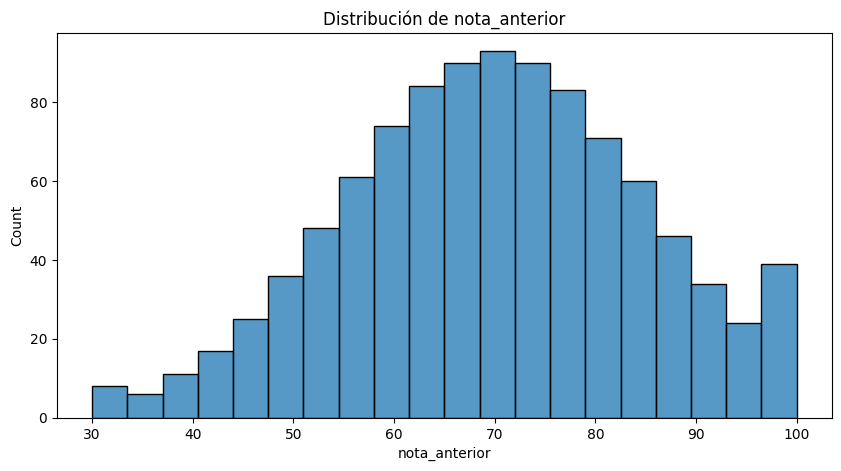

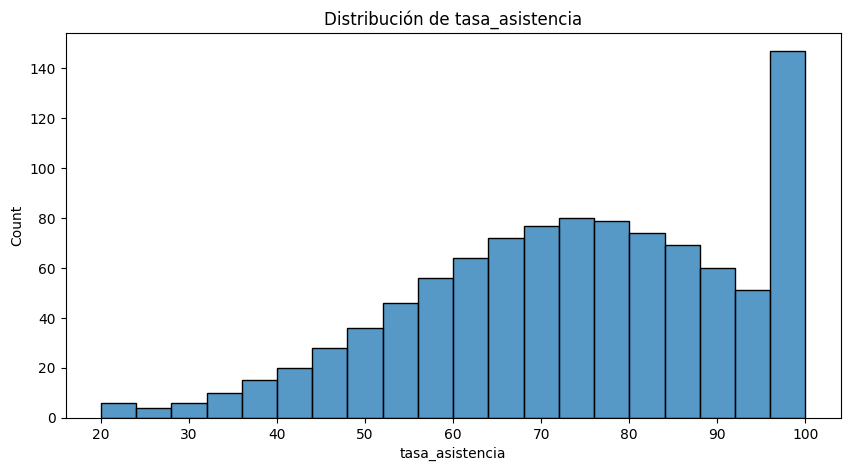

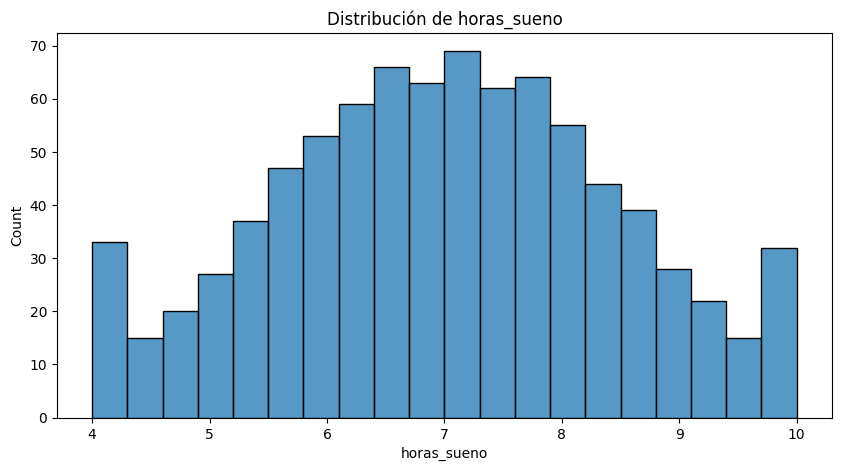

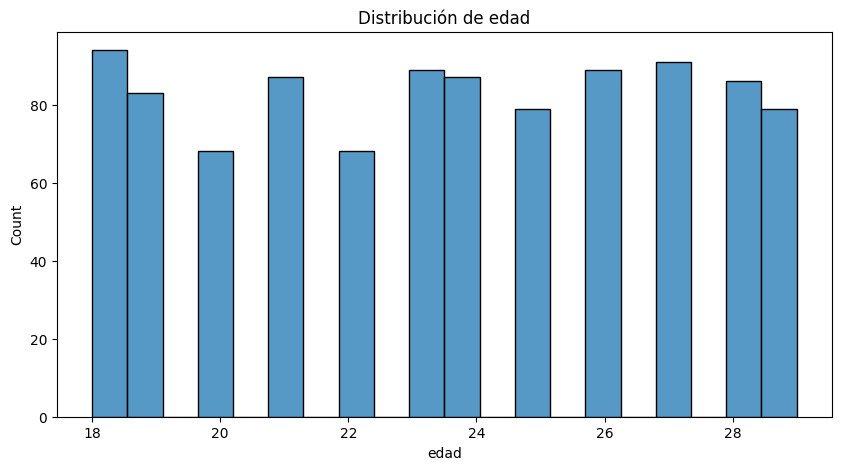

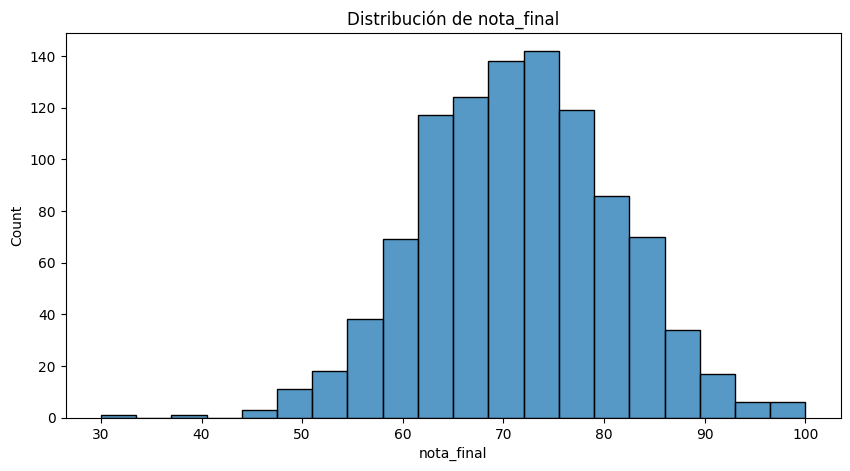

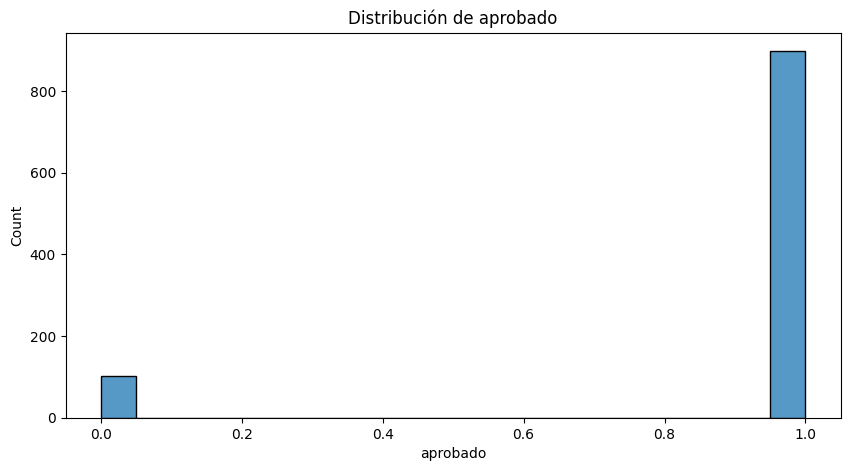

In [24]:
for col in num_cols:
    plt.figure(figsize=(10,5))
    sns.histplot(estudiantes[col], bins=20)

    plt.title (f'Distribución de {col}')
    plt.xlabel(col)
    plt.show()

### Categorías

In [25]:
estudiantes = estudiantes.reset_index(drop=True)

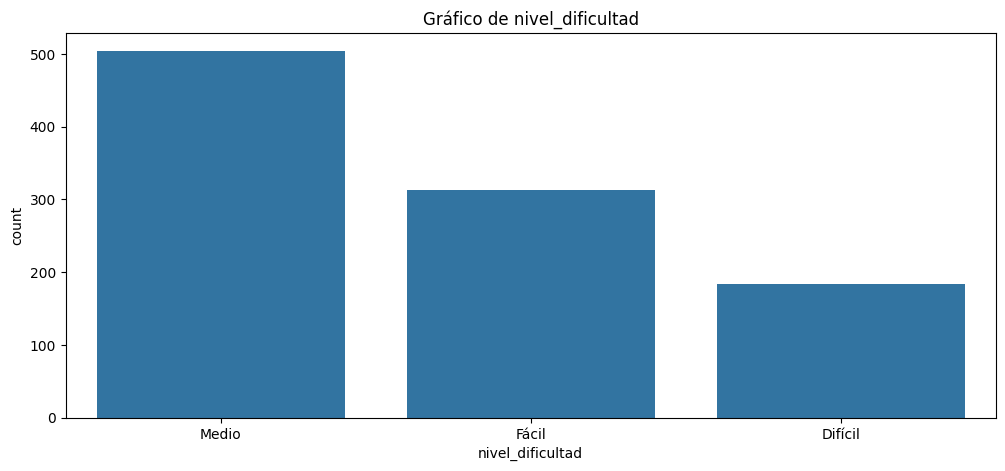

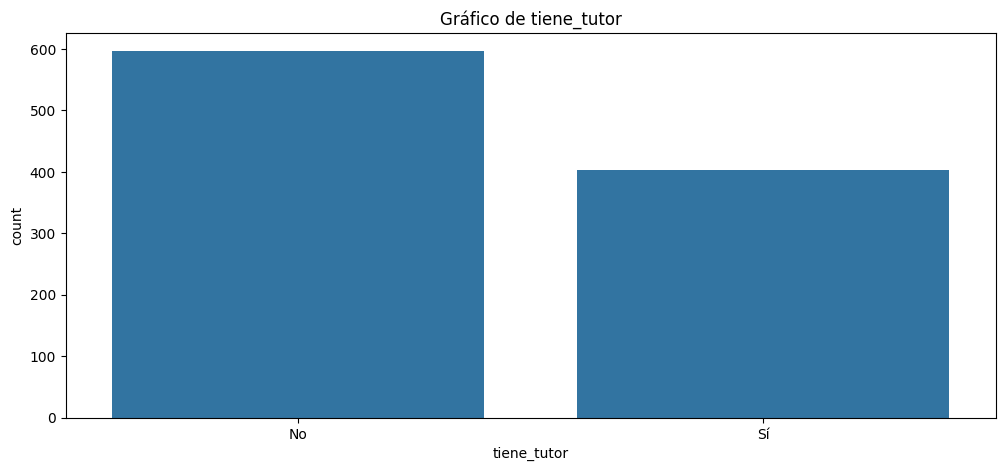

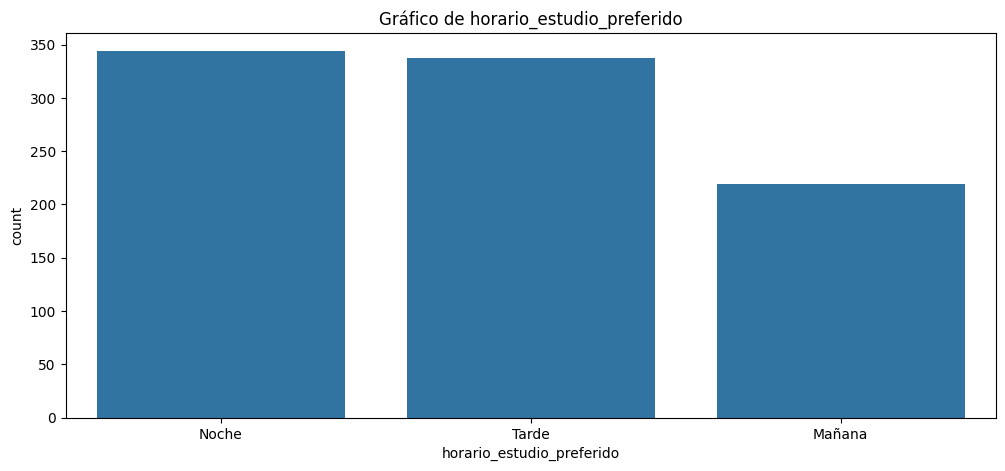

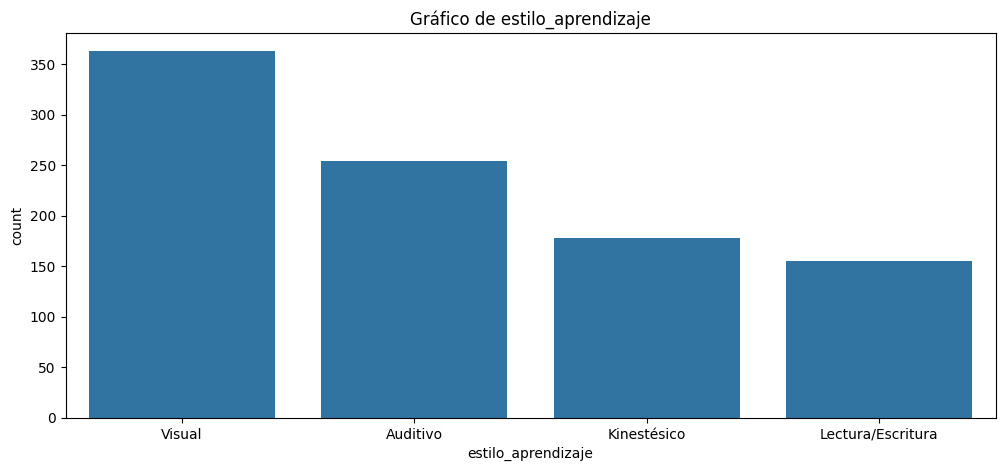

In [26]:
for col in cat_cols:
    num_categories = estudiantes[col].nunique()
    orden_categorias = estudiantes[col].value_counts().index

    plt.figure(figsize=(12,5))
    sns.countplot(data=estudiantes, x=col, order=orden_categorias)

    plt.title(f'Gráfico de {col}')
    plt.xticks(rotation=0)
    plt.show()

### Matriz de correlacion

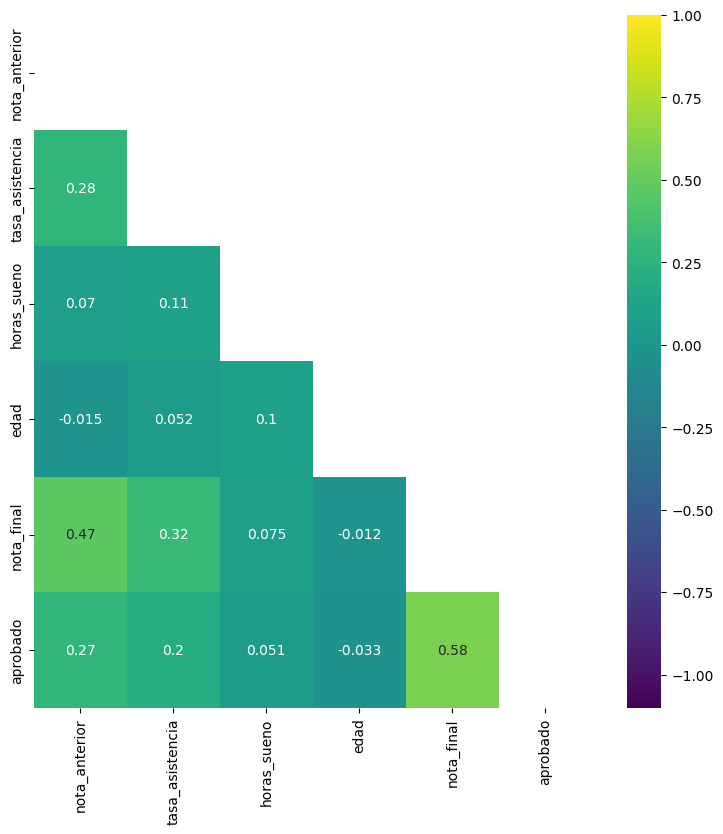

In [27]:
matriz_correlacion=estudiantes.corr(numeric_only=True)

plt.figure(figsize=(9,9))

mask= np.triu(np.ones_like(matriz_correlacion, dtype=bool))


sns.heatmap(matriz_correlacion, annot=True, vmin=1,vmax=-1, mask=mask, cmap="viridis")
plt.show()

## Relaciones cruzadas

- Regresion: nota_final (variable continua entre 0 y 100)  
- Clasificacion: aprobado (variable binaria: 1 si la nota es ≥ 60, 0 en caso contrario)

#### Variable regresion nota_final

In [28]:
#definimos la variable objetivo
tv= 'nota_final'

#Nos quedamos solo con las columnas numéricas y excluimos la variable objetivo.
estudiantes_num= estudiantes.select_dtypes(include=np.number).drop(columns=[tv], errors='ignore')
cols_num=estudiantes_num.columns

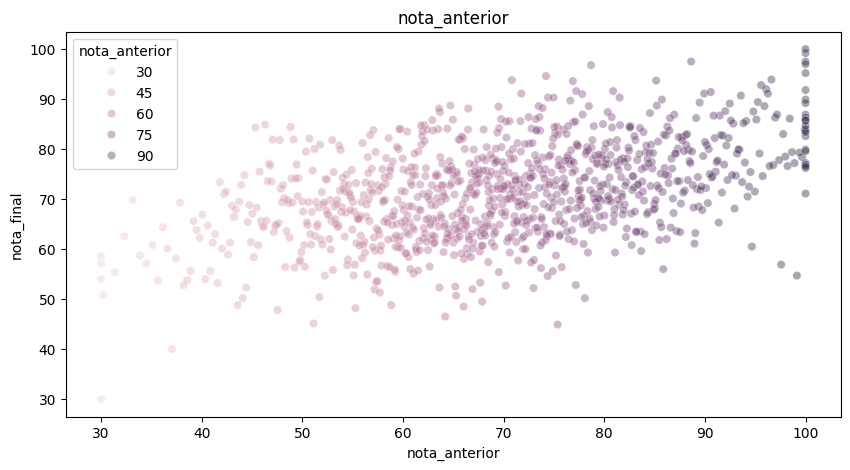

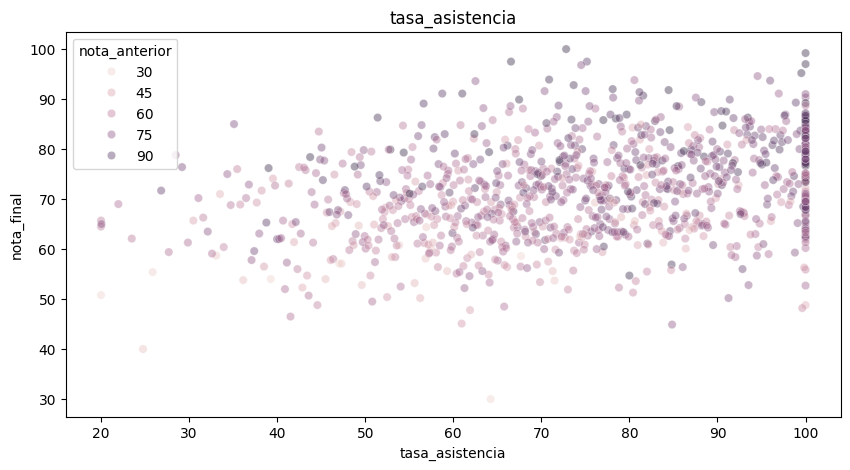

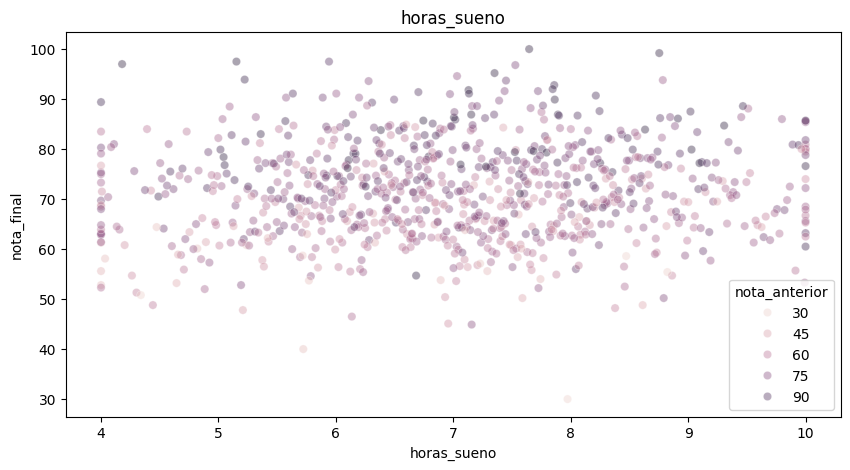

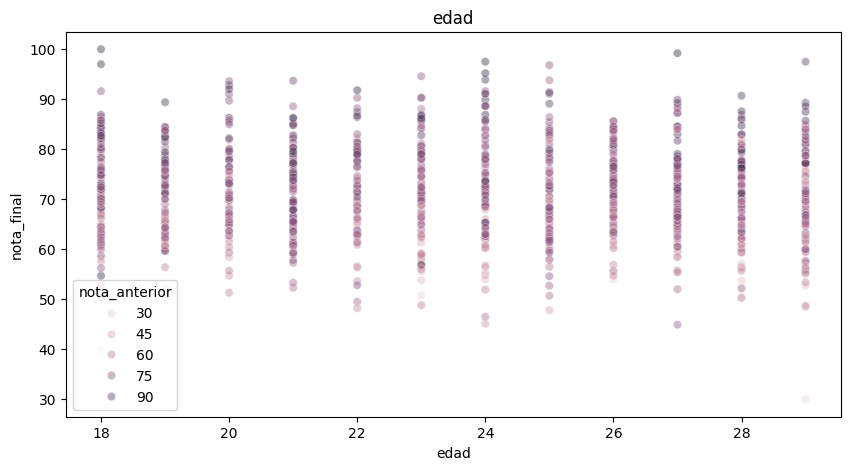

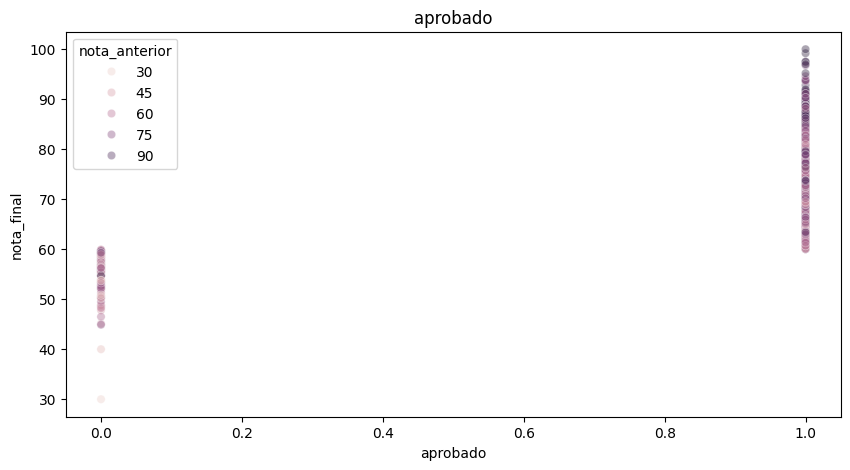

In [29]:
for col in cols_num:
    plt.figure(figsize=(10,5))
    sns.scatterplot(x=estudiantes[col], y=estudiantes[tv], hue=estudiantes['nota_anterior'], alpha= 0.4)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel(tv)
    plt.show()

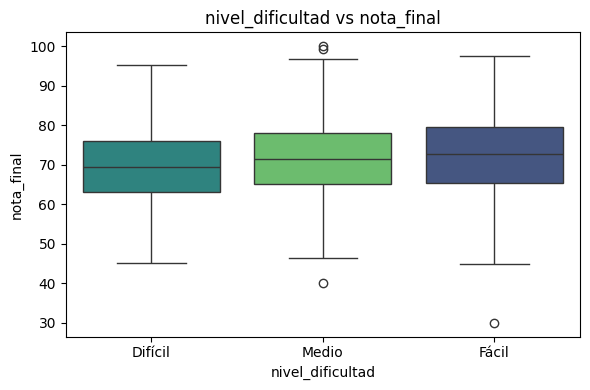

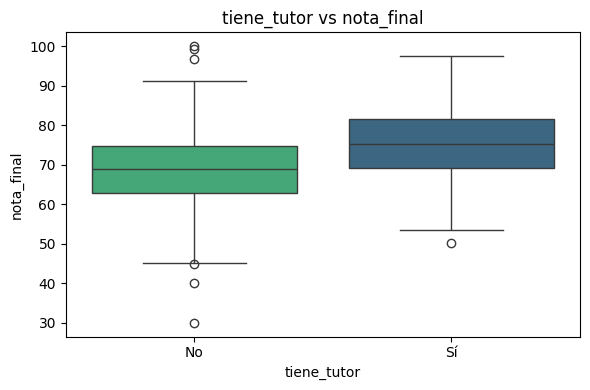

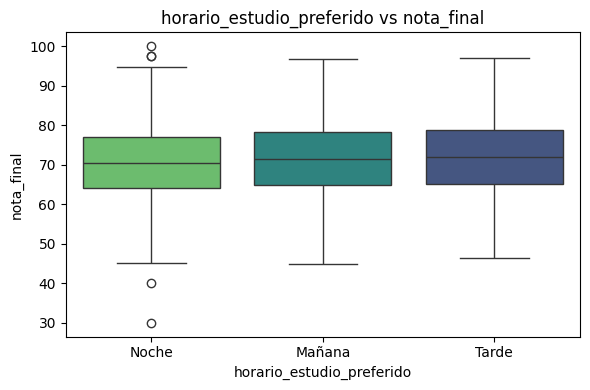

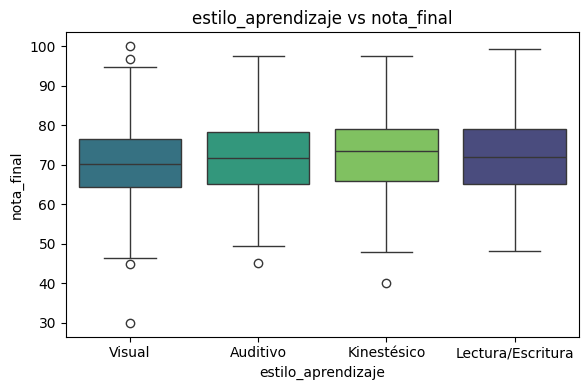

In [30]:
# Definir la variable objetivo
tv = 'nota_final'

# Generar gráficos independientes para cada variable categórica
for col in cat_cols:
    num_cats = estudiantes[col].nunique()
    fig_width = min(max(6, num_cats * 1.5), 25)
    fig_height = 4

    ordered_cats = estudiantes.groupby(col)[tv].mean().sort_values().index

    plt.figure(figsize=(fig_width, fig_height))
    sns.boxplot(x=estudiantes[col], y=estudiantes[tv], hue=estudiantes[col], data=estudiantes, order=ordered_cats, palette="viridis", legend=False)
    
    plt.title(f"{col} vs {tv}")
    plt.xlabel(col)
    plt.ylabel(tv)
    plt.tight_layout()
    plt.show()

## Variable clasificacion Aprobado

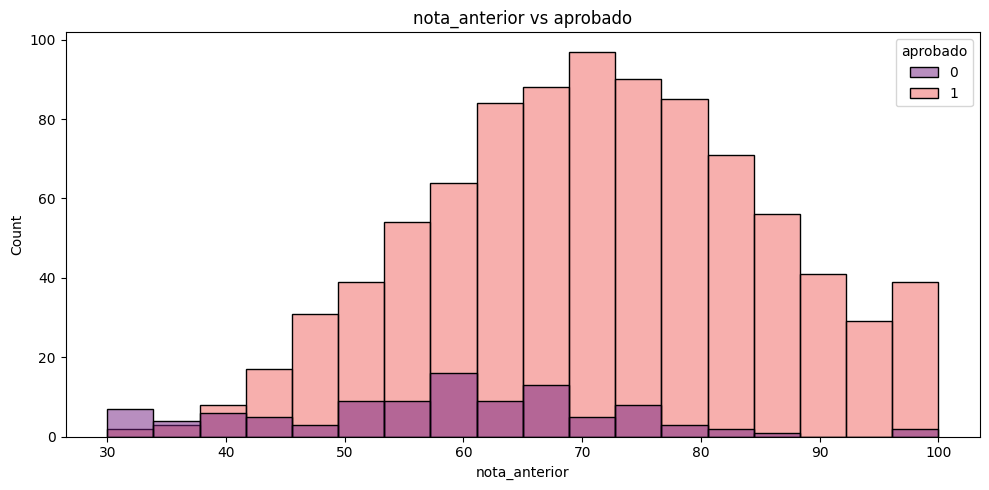

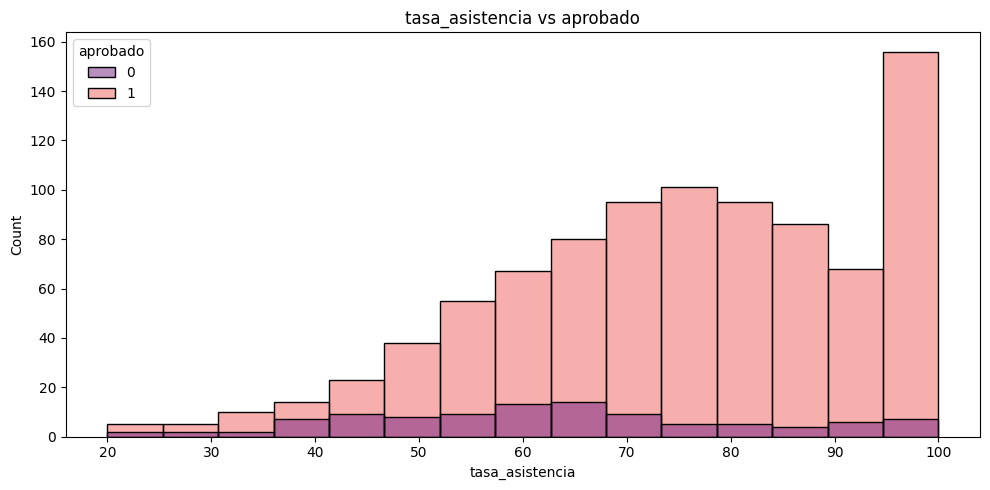

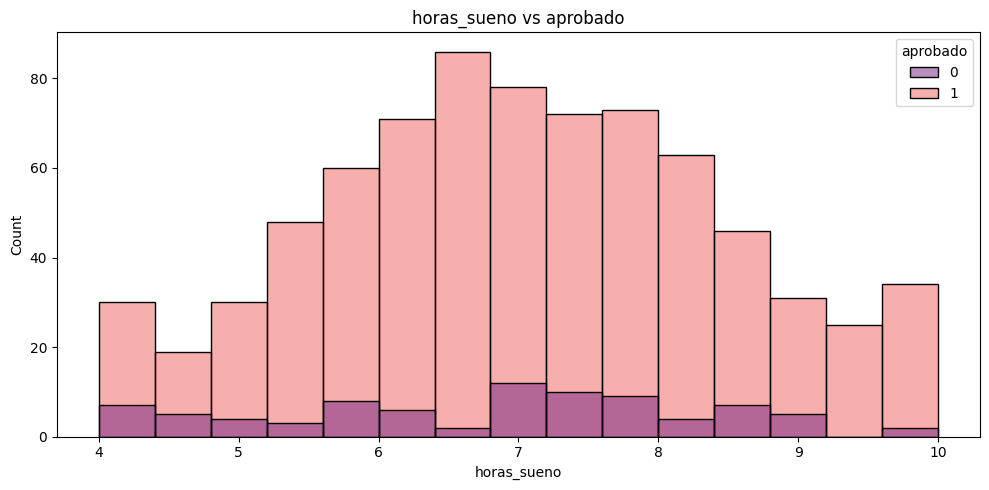

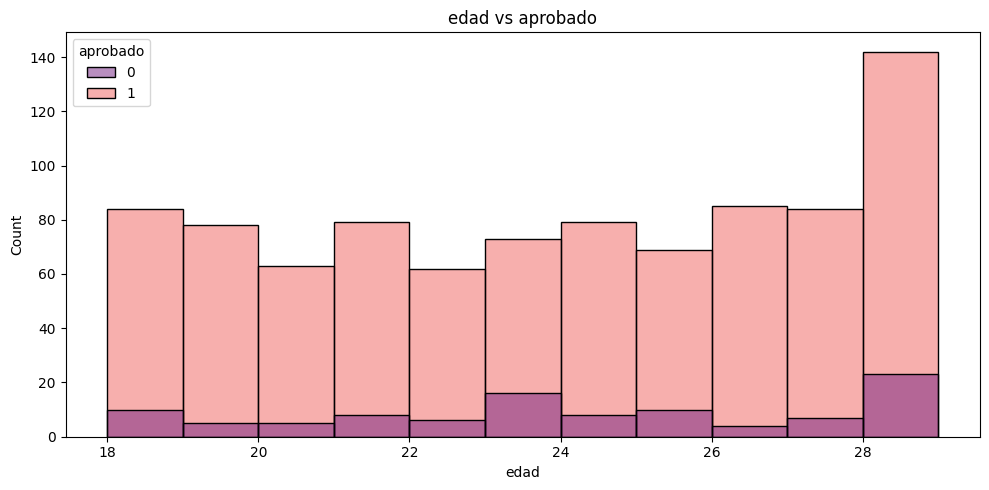

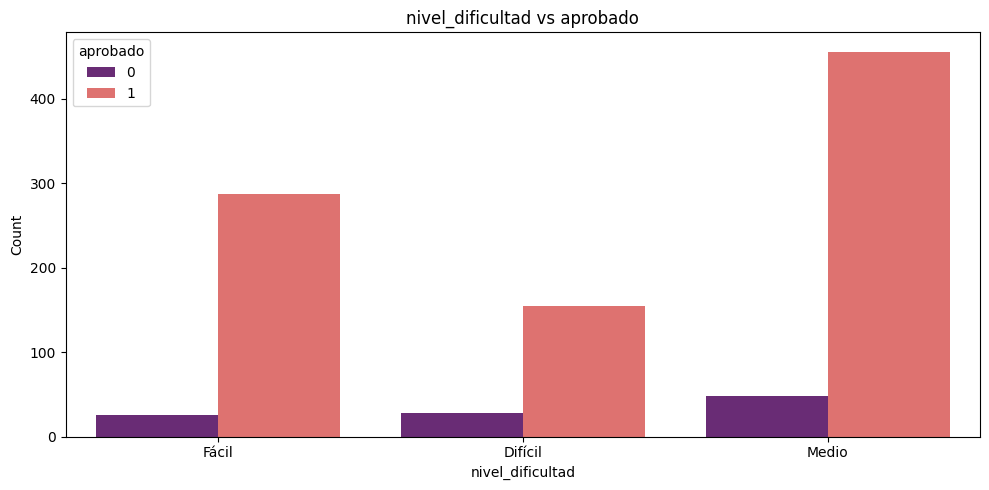

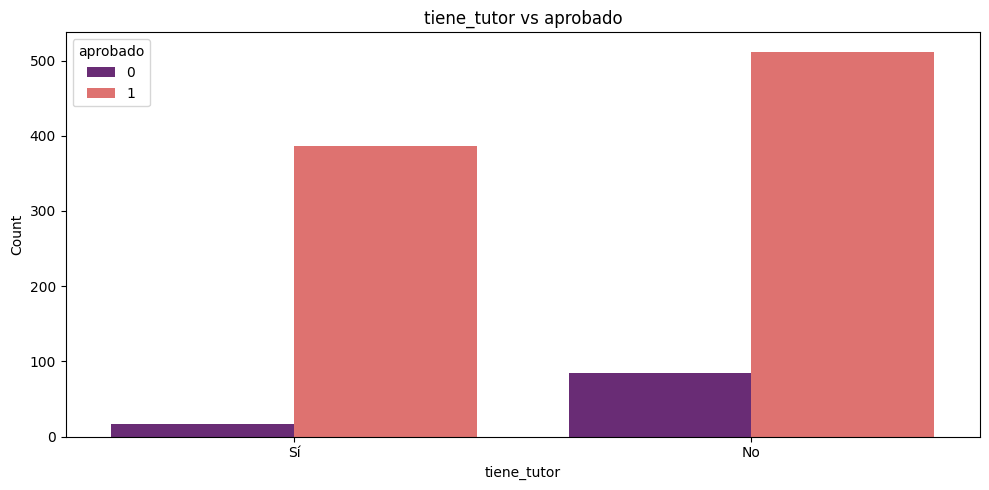

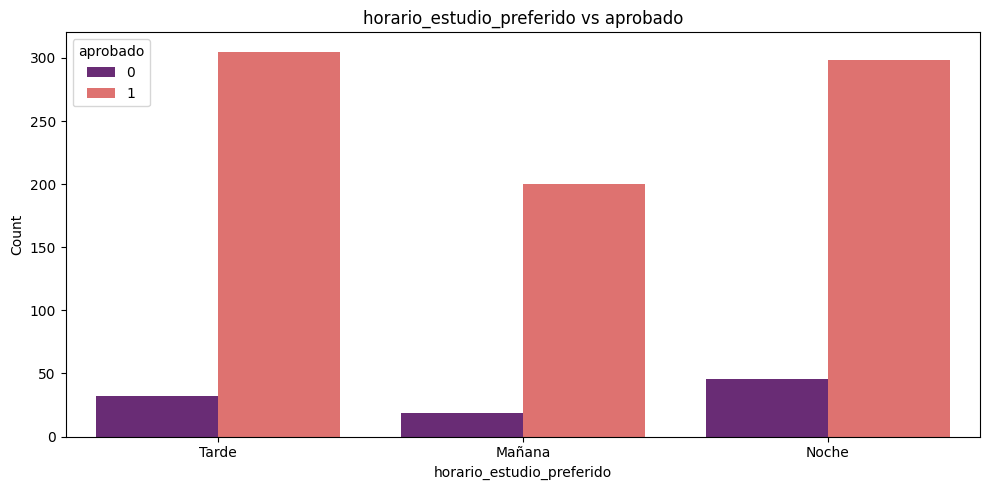

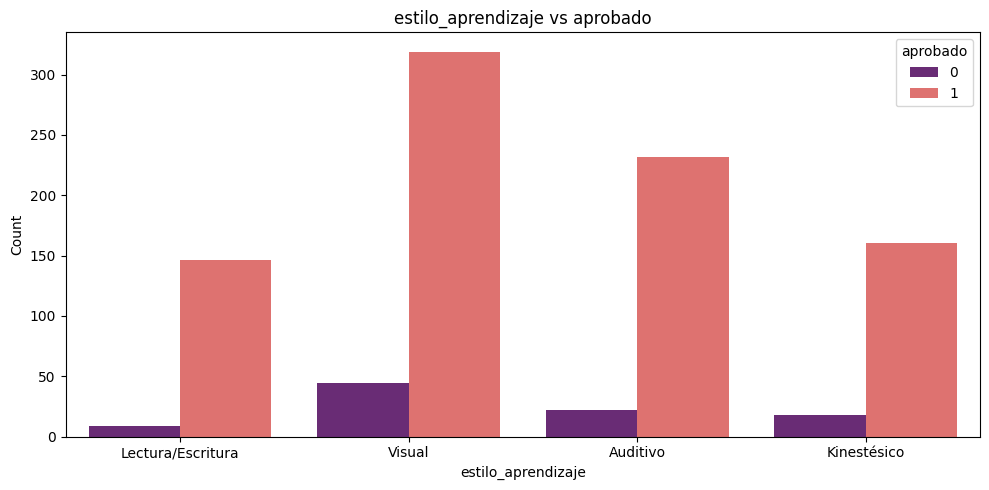

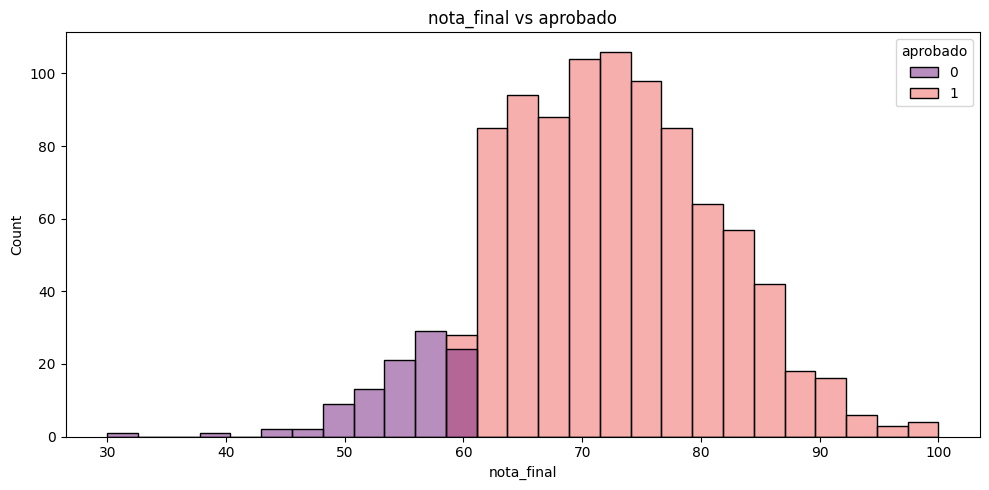

In [31]:
# Definir la variable objetivo
tv = 'aprobado'

for col in estudiantes.columns:
    # Saltar la variable objetivo
    if col == tv:
        continue

    plt.figure(figsize=(10, 5))

    if col in num_cols:
        sns.histplot(x=estudiantes[col], hue=estudiantes[tv], data=estudiantes, palette="magma", legend=True)
    elif col in cat_cols:
        sns.countplot(x=estudiantes[col], hue=estudiantes[tv], data=estudiantes, palette="magma")

    plt.title(f"{col} vs {tv}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


### Inconsistencias

In [35]:
inconsistencias = []

# Regla 1: La asistencia no puede superar el 100% (nadie va más veces de las que hay clase)
mask = estudiantes['tasa_asistencia'] > 100
for i in estudiantes.index[mask]:
    inconsistencias.append((i, 'tasa_asistencia > 100%'))

# Regla 2: Nota final fuera de rango
mask = (estudiantes['nota_final'] > 100) | (estudiantes['nota_final'] < 0)
for i in estudiantes.index[mask]:
    inconsistencias.append((i, 'nota_final fuera de rango'))

# Regla 3: Nota baja pero marcado como aprobado
mask = (estudiantes['nota_final'] < 60) & (estudiantes['aprobado'] == 1)
for i in estudiantes.index[mask]:
    inconsistencias.append((i, 'Nota < 60 pero aparece como aprobado (1)'))

# Regla 4: Nota alta pero marcado como suspenso
mask = (estudiantes['nota_final'] >= 60) & (estudiantes['aprobado'] == 0)
for i in estudiantes.index[mask]:
    inconsistencias.append((i, 'Nota >= 60 pero aparece como suspenso (0)'))

# Regla 5: Edad poco realista para el nivel académico
mask = estudiantes['edad'] < 6
for i in estudiantes.index[mask]:
    inconsistencias.append((i, 'Edad demasiado baja (<6)'))

# Creamos DataFrame de inconsistencias
inconsistencies_estudiantes = pd.DataFrame(inconsistencias, columns=['Index', 'Inconsistency'])

# Obtenemos los índices únicos y filtrar el original
inconsistent_indices = inconsistencies_estudiantes['Index'].unique()
estudiantes_inconsistent_rows = estudiantes.loc[inconsistent_indices]

print(f"Se han encontrado {len(estudiantes_inconsistent_rows)} filas con errores lógicos.")

Se han encontrado 0 filas con errores lógicos.


No es necesario corregir ninguna inconsistencia